In [1]:
import jax
import jax.numpy as jnp
from jax import value_and_grad, jit, vmap
import openmm.app as apps
import openmm.unit as unit
from openmm import app
from openmm.app import ForceField

from dmff import Hamiltonian, NeighborList
from dmff.api.xmlio import XMLIO
from dmff.api.paramset import ParamSet
from dmff.operators.templatetype import TemplateATypeOperator
import dmff
from dmff.generators.classical import PeriodicTorsionGenerator, NonbondedGenerator

import copy
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

from ase.io import read,write
from ase.visualize import view

from imolcryff.molinfo import load_molinfo

/Users/srak/.local/lib/python3.12/site-packages/dmff/admp/qeq.py:33: UserWarning: jaxopt not found, QEQ cannot be used.
  warnings.warn("jaxopt not found, QEQ cannot be used.")


In [2]:
class PeriodicTorsionGenerator_rev(PeriodicTorsionGenerator):
    def overwrite(self, paramset):
        # paramset to ffinfo
        proper_node_indices = [i for i in range(len(
            self.ffinfo["Forces"][self.name]["node"])) if self.ffinfo["Forces"][self.name]["node"][i]["name"] == "Proper"]
        improper_node_indices = [i for i in range(len(
            self.ffinfo["Forces"][self.name]["node"])) if self.ffinfo["Forces"][self.name]["node"][i]["name"] == "Improper"]

        proper_phase = paramset[self.name]["proper_phase"]
        proper_k = paramset[self.name]["proper_k"]
        proper_msks = paramset.mask[self.name]["proper_k"]
        for nnode, key in enumerate(self.proper_keys):
            self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]]["attrib"] = {
            }
            self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}1"] = key[0]
            self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}2"] = key[1]
            self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}3"] = key[2]
            self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}4"] = key[3]
            for nitem, item in enumerate(self.proper_key_to_prms[nnode]):
                phase, k = proper_phase[item], proper_k[item]
                mask = proper_msks[item]
                self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                         ]["attrib"]["periodicity" + str(nitem + 1)] = str(self.proper_periods[item])
                self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                         ]["attrib"]["phase" + str(nitem + 1)] = str(phase)
                self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                         ]["attrib"]["k" + str(nitem + 1)] = str(k)
            if mask < 0.999:
                self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                         ]["attrib"]["mask"] = "true"

        improper_phase = paramset[self.name]["improper_phase"]
        improper_k = paramset[self.name]["improper_k"]
        improper_msks = paramset.mask[self.name]["improper_k"]
        for nnode, key in enumerate(self.imp_keys):
            self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]]["attrib"] = {
            }
            self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}1"] = key[0]
            self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}2"] = key[1]
            self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}3"] = key[2]
            self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}4"] = key[3]
            for nitem, item in enumerate(self.imp_key_to_prms[nnode]):
                phase = improper_phase[item]
                k = improper_k[item]
                mask = improper_msks[item]
                self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                         ]["attrib"]["periodicity" + str(nitem + 1)] = str(self.imp_periods[item])
                self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                         ]["attrib"]["phase" + str(nitem + 1)] = str(phase)
                self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                         ]["attrib"]["k" + str(nitem + 1)] = str(k)
            if mask < 0.999:
                self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                         ]["attrib"]["mask"] = "true"

In [3]:
ff = Hamiltonian("gaffxml_0.xml")
molinfo = load_molinfo("mol_info.pkl")
mmm = molinfo.get_molecule_omm()
top = mmm[0].to_topology().to_openmm()
potentials = ff.createPotential(top)
efunc = potentials.getPotentialFunc()

io = XMLIO()
io.loadXML("gaffxml_0.xml")
ffinfo = io.parseXML()
topdata = dmff.DMFFTopology(top)
operator = TemplateATypeOperator(ffinfo)
operator.operate(topdata)
for na, a in enumerate(topdata._meta):
    print(a)
paramset_dihed = ParamSet()
torsion_gen = PeriodicTorsionGenerator(ffinfo, paramset_dihed)

[01:49:00] atom 10 has specified valence (1) smaller than the drawn valence 2.


In [55]:
forcefield = ForceField("gaffxml_0.xml")
system = forcefield.createSystem(mmm[0].to_topology().to_openmm(), nonbondedMethod=app.NoCutoff)
molinfo.get_dihedral_ff(forcefield)

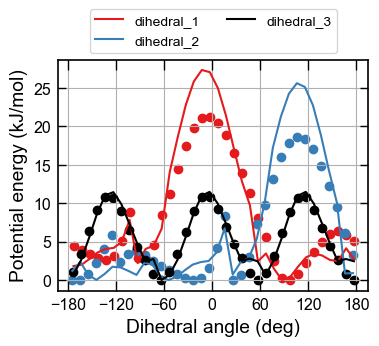

In [57]:
from imolcryff.molinfo import draw_dihedral_plots
gt, ff_scan = draw_dihedral_plots(molinfo, "MOL_0")

In [15]:
@jit
def MSELoss(params0: ParamSet, ffparams, positions, box, pairs, gt_Etot):
    kT = 2.494 # 300 K = 2.494 kJ/mol
    assert len(positions) == len(gt_Etot)
    assert len(positions) == len(pairs)
    
    gt_Etot = gt_Etot - gt_Etot.min()
    gt_Etot = jnp.array(gt_Etot)
    weights_pts = jnp.piecewise(gt_Etot, [gt_Etot<25, gt_Etot>=25], [lambda x: jnp.array(1.0), lambda x: jnp.exp(-(x-25)/kT)])
    npts = len(weights_pts)
    
    # setting up params for all calculators
    params_dihed = {} 
    params_dihed["PeriodicTorsionForce"] = {}
    params_dihed["PeriodicTorsionForce"]["proper_phase"] = params0["PeriodicTorsionForce"]["proper_phase"]
    params_dihed["PeriodicTorsionForce"]["proper_k"] = params0["PeriodicTorsionForce"]["proper_k"]

    p = copy.deepcopy(ffparams)
    p['PeriodicTorsionForce']["proper_phase"] = params_dihed["PeriodicTorsionForce"]["proper_phase"]
    p['PeriodicTorsionForce']["proper_k"] = params_dihed["PeriodicTorsionForce"]["proper_k"]

    # calculate each points, only the short range and damping components
    totene_ff = jnp.zeros(npts)
    for ipt in range(npts):
        totene_ff = totene_ff.at[ipt].set(efunc(positions[ipt], box, pairs[ipt], p))
    
    totene_ff = totene_ff - totene_ff.min()
        
    dE = totene_ff - gt_Etot
    mse = dE**2 * weights_pts / jnp.sum(weights_pts)
    mse = jnp.sum(mse)

    return mse

In [6]:
def get_relaxedcoord_dihedconst(top, positions_ary, dihed_atomid, dihed_angle, ffxml):
    from openmm.unit import degree, kilojoules_per_mole, kelvin, picosecond, picoseconds
    from openmm.app import NoCutoff, Simulation
    from openmm import PeriodicTorsionForce, LangevinMiddleIntegrator
    from openmm.app import PDBFile
    positions_list = []
    for i_angle, angle_deg in enumerate(dihed_angle):
        forcefield = ForceField(ffxml)
        system = forcefield.createSystem(top, nonbondedMethod=NoCutoff)
        restraint = PeriodicTorsionForce()
        d1 = dihed_atomid[0]
        d2 = dihed_atomid[1]
        d3 = dihed_atomid[2]
        d4 = dihed_atomid[3]
        restraint.addTorsion(d1,d2,d3,d4, 1, (angle_deg+180)*degree, 1000*kilojoules_per_mole)
        system.addForce(restraint)
        integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, 0.004*picoseconds)
        simulation = Simulation(top, system, integrator)
        simulation.context.setPositions(positions_ary[i_angle])
        simulation.minimizeEnergy()
        state = simulation.context.getState(getPositions=True, getEnergy=True)
        positions_list.append(state.getPositions(asNumpy=True))
    return positions_list

In [7]:
def get_pospairs_dihedral(molinfo_dict, top, dihed_idx, ffxml):
    dihed_angle = molinfo_dict["dihedral_angle"][dihed_idx]
    dihed_atomid = molinfo_dict['rotatable_dihedral'][dihed_idx]
    dihed_ase = molinfo_dict['dihedral_aseatoms'][dihed_idx]
    positions_ary = np.array([np.array(dihed_ase[i].positions / 10) for i in range(len(dihed_ase))])
    positions = get_relaxedcoord_dihedconst(top, positions_ary, dihed_atomid, dihed_angle, ffxml)
    jnp_positions = jnp.array([jnp.array(positions[i]) for i in range(len(positions))])

    box = jnp.array([
            [1000.0,  0.0,  0.0],
            [ 0.0, 1000.0,  0.0],
            [ 0.0,  0.0, 1000.0]
        ])

    jnp_pairs= []
    for i_dihed in range(len(dihed_ase)):
        nbList = NeighborList(box, rcut=40, cov_map=potentials.meta["cov_map"])
        nbList.allocate(jnp_positions[i_dihed])
        jnp_pairs.append(nbList.pairs)

    jnp_pairs = jnp.array(jnp_pairs)

    return jnp_positions, box, jnp_pairs

def get_gt_Etot(molinfo, molname, idx):
    from ase import units
    gt_Etot = molinfo.mol_info[molname]["dihedral_energy"][idx]
    gt_Etot = (gt_Etot - gt_Etot.min()) / (units.kJ * (units.mol**-1))
    gt_Etot = jnp.array(gt_Etot)
    return gt_Etot

In [8]:
ff.getParameters().to_jax()
paramset0 = ff.getParameters()
paramset0

In [16]:
jnp_positions, jnp_box, jnp_pairs = get_pospairs_dihedral(molinfo.mol_info["MOL_0"], top, 1, "gaffxml_0.xml")
dihedral_qm = get_gt_Etot(molinfo, "MOL_0", 1)
a = MSELoss(paramset0, paramset0, jnp_positions, jnp_box, jnp_pairs, dihedral_qm)
print(a)

8.149578799936666


In [17]:
MSELoss_grad = jit(value_and_grad(MSELoss, argnums=(0)))
err, gradients = MSELoss_grad(paramset0, paramset0, jnp_positions, jnp_box, jnp_pairs, dihedral_qm)

In [18]:
def add_grad(grad1:ParamSet, grad2:ParamSet):
    for k in grad1.parameters.keys():
        for t in grad1.parameters[k].keys():
            grad1.parameters[k][t] += grad2.parameters[k][t]
    return ParamSet(grad1.parameters, grad1.mask)

In [20]:
import optax
import sys
# start to do optmization


lr = 0.01
opt = optax.adam(lr)

opt_state = opt.init(paramset_dihed)

jnp_positions_list = []
jnp_box_list = []
jnp_pairs_list = []
dihedral_qm_list = []
for i, i_dihed in enumerate([1,2,3]):
    jnp_positions, jnp_box, jnp_pairs = get_pospairs_dihedral(molinfo.mol_info["MOL_0"], top, i_dihed, "gaffxml_0.xml")
    dihedral_qm = get_gt_Etot(molinfo, "MOL_0", i_dihed)
    jnp_positions_list.append(jnp_positions)
    jnp_box_list.append(jnp_box)
    jnp_pairs_list.append(jnp_pairs)
    dihedral_qm_list.append(dihedral_qm)

n_epochs = 200000
best_loss = 1e10
for i_epoch in range(1,n_epochs+1):
    for i, i_dihed in enumerate([1,2,3]):
        loss_tmp, grads_tmp = MSELoss_grad(paramset_dihed, paramset0, jnp_positions_list[i], jnp_box_list[i], jnp_pairs_list[i], dihedral_qm_list[i])
        if i == 0:
            loss = loss_tmp
            grads = grads_tmp
        else:
            loss += loss_tmp
            grads = add_grad(grads, grads_tmp)

    if loss < best_loss:
        best_loss = loss
        best_params = paramset_dihed
    sys.stdout.flush()
    # updates, opt_state = opt.update(grads, opt_state, value=loss)
    updates, opt_state = opt.update(grads, opt_state)
    paramset_dihed = optax.apply_updates(paramset_dihed, updates)
    # paramset_dihed = jax.tree_map(lambda x: jnp.clip(x, 0.0, 1e8), paramset_dihed)
    torsion_gen.overwrite(paramset_dihed)

    if i_epoch % 100 == 0:
        print(f"epoch: {i_epoch}, loss: {loss}")
    if i_epoch % 10000 == 0:
        io.writeXML(f"loop-{i_epoch}.xml", ffinfo)

epoch: 100, loss: 14.491929793700415
epoch: 200, loss: 13.930743249300065
epoch: 300, loss: 13.41901157739283
epoch: 400, loss: 12.883398428746755
epoch: 500, loss: 12.332769407648435
epoch: 600, loss: 11.791108389140309
epoch: 700, loss: 11.268714238563806
epoch: 800, loss: 10.771387257927767
epoch: 900, loss: 10.303019832212854
epoch: 1000, loss: 9.866724470457203
epoch: 1100, loss: 9.462406252018045
epoch: 1200, loss: 9.115273588653668
epoch: 1300, loss: 8.740971552267762
epoch: 1400, loss: 8.428570520483774
epoch: 1500, loss: 8.141855999639745
epoch: 1600, loss: 7.879688827520705
epoch: 1700, loss: 7.640706616199797
epoch: 1800, loss: 7.418819198706171
epoch: 1900, loss: 7.208466087791137
epoch: 2000, loss: 7.018076675037754
epoch: 2100, loss: 6.844232541775829
epoch: 2200, loss: 6.714740594427208
epoch: 2300, loss: 6.546199241754626
epoch: 2400, loss: 6.418663867201904
epoch: 2500, loss: 6.302248910132517
epoch: 2600, loss: 6.198833043590033
epoch: 2700, loss: 6.104107878615822
ep

KeyboardInterrupt: 

In [21]:
import pickle
with open('params.pickle', 'wb') as ofile:
    pickle.dump(best_params, ofile)

In [22]:
import pickle
with open('params.pickle',"rb") as ofile:
    best_params = pickle.load(ofile)

torsion_gen.overwrite(best_params)
io.writeXML("best.xml", ffinfo)

In [24]:
def ff_dihed(jnp_positions_ary, params):
    # dihed_ase = molinfo.mol_info["MOL_0"]["dihedral_aseatoms"][id]
    totenes = []
    for i_dihed in range(len(jnp_positions_ary)):
        jnp_positions = jnp_positions_ary[i_dihed]
        box = jnp.array([
            [1000.0,  0.0,  0.0],
            [ 0.0, 1000.0,  0.0],
            [ 0.0,  0.0, 1000.0]
        ])
        nbList = NeighborList(box, rcut=40, cov_map=potentials.meta["cov_map"])
        nbList.allocate(jnp_positions)
        pairs = nbList.pairs
        efunc = potentials.getPotentialFunc()
        totene = efunc(jnp_positions, box, pairs, params)
        totenes.append(totene)
    totenes = np.array(totenes)
    return totenes

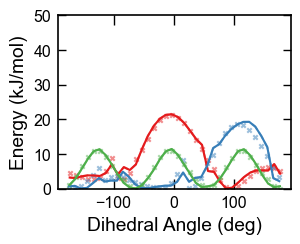

In [53]:
cmap = plt.get_cmap('Set1')
from ase import units
best_params = Hamiltonian("best.xml").getParameters()
plt.ylim(0, 50)
plt.xlabel("Dihedral Angle (deg)")
plt.ylabel("Energy (kJ/mol)")
for id in [0,1,2]:
    totenes = ff_dihed(jnp_positions_list[id], best_params)
    totenes = totenes - totenes.min()
    dihed = molinfo.mol_info["MOL_0"]["dihedral_angle"][id+1]
    plt.plot(dihed,totenes,color=cmap(id))
    # gt = (molinfo.mol_info["MOL_0"]["dihedral_energy"][id] - molinfo.mol_info["MOL_0"]["dihedral_energy"][id].min()) / (units.kJ * (units.mol**-1))
    plt.scatter(dihed, gt[id+1],color=cmap(id),marker='x',s=10,alpha=0.5)
    plt.plot(dihed, totenes,color=cmap(id),alpha=0.5,linestyle='--')

In [16]:
# from dmff.api.xmlio import XMLIO
# from dmff.api.paramset import ParamSet
# from dmff.operators.templatetype import TemplateATypeOperator
# import dmff
# from dmff.generators.classical import PeriodicTorsionGenerator

# io = XMLIO()
# io.loadXML("gaffxml_0.xml")
# ffinfo = io.parseXML()

In [17]:
# import xml.etree.ElementTree as ET

# def xmlrender(file1, file2, file3):
#     """
#     file1: torsion.xml
#     file2: res.xml
#     file3: output.xml
#     """
#     torsion_tree = ET.parse(file1)
#     torsion_root = torsion_tree.getroot()

#     fullff_tree = ET.parse(file2)
#     fullff_root = fullff_tree.getroot()

#     fullff_torsion_force_element = fullff_root.find(".//PeriodicTorsionForce")

#     torsion_force_element = torsion_root.find(".//PeriodicTorsionForce")

#     for atom_element in torsion_force_element:
#         fullff_torsion_force_element.append(atom_element)
        
#     combined_tree = ET.ElementTree(fullff_root)
#     combined_tree.write(file3, encoding='utf-8')

In [18]:
# class PeriodicTorsionGenerator_rev(PeriodicTorsionGenerator):
#     def overwrite(self, paramset):
#         # paramset to ffinfo
#         proper_node_indices = [i for i in range(len(
#             self.ffinfo["Forces"][self.name]["node"])) if self.ffinfo["Forces"][self.name]["node"][i]["name"] == "Proper"]
#         improper_node_indices = [i for i in range(len(
#             self.ffinfo["Forces"][self.name]["node"])) if self.ffinfo["Forces"][self.name]["node"][i]["name"] == "Improper"]

#         proper_phase = paramset[self.name]["proper_phase"]
#         proper_k = paramset[self.name]["proper_k"]
#         proper_msks = paramset.mask[self.name]["proper_k"]
#         for nnode, key in enumerate(self.proper_keys):
#             self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]]["attrib"] = {
#             }
#             self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}1"] = key[0]
#             self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}2"] = key[1]
#             self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}3"] = key[2]
#             self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}4"] = key[3]
#             for nitem, item in enumerate(self.proper_key_to_prms[nnode]):
#                 phase, k = proper_phase[item], proper_k[item]
#                 mask = proper_msks[item]
#                 self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                          ]["attrib"]["periodicity" + str(nitem + 1)] = str(self.proper_periods[item])
#                 self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                          ]["attrib"]["phase" + str(nitem + 1)] = str(phase)
#                 self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                          ]["attrib"]["k" + str(nitem + 1)] = str(k)
#             if mask < 0.999:
#                 self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                          ]["attrib"]["mask"] = "true"

#         improper_phase = paramset[self.name]["improper_phase"]
#         improper_k = paramset[self.name]["improper_k"]
#         improper_msks = paramset.mask[self.name]["improper_k"]
#         for nnode, key in enumerate(self.imp_keys):
#             self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]]["attrib"] = {
#             }
#             self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}1"] = key[0]
#             self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}2"] = key[1]
#             self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}3"] = key[2]
#             self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}4"] = key[3]
#             for nitem, item in enumerate(self.imp_key_to_prms[nnode]):
#                 phase = improper_phase[item]
#                 k = improper_k[item]
#                 mask = improper_msks[item]
#                 self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                          ]["attrib"]["periodicity" + str(nitem + 1)] = str(self.imp_periods[item])
#                 self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                          ]["attrib"]["phase" + str(nitem + 1)] = str(phase)
#                 self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                          ]["attrib"]["k" + str(nitem + 1)] = str(k)
#             if mask < 0.999:
#                 self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                          ]["attrib"]["mask"] = "true"

In [19]:
# from dmff.operators.templatetype import TemplateATypeOperator
# import dmff
# from dmff.generators.classical import PeriodicTorsionGenerator
# from imolcryff.molinfo import load_molinfo

# print(dmff.__file__)
# molinfo = load_molinfo("mol_info.pkl")
# mmm = molinfo.get_molecule_omm()
# top = mmm[0].to_topology().to_openmm()
# topdata = dmff.DMFFTopology(top)

# io = XMLIO()
# io.loadXML("gaffxml_0.xml")
# ffinfo = io.parseXML()
# operator = TemplateATypeOperator(ffinfo)
# operator.operate(topdata)
# for na, a in enumerate(topdata._meta):
#     print(a)
# paramset = ParamSet()
# torsion_gen = PeriodicTorsionGenerator_rev(ffinfo, paramset)

# ####
# # paramset = optax.apply_updates(paramset, updates)

# # paramset = jax.tree_map(lambda x: jnp.clip(x, 0.0, 1e8), paramset)

# torsion_gen.overwrite(paramset)
# io.writeXML(f"loop-.xml", ffinfo)

In [20]:
# from dmff.generators.classical import NonbondedGenerator
# from dmff.operators.templatetype import TemplateATypeOperator
# import dmff

# top = mmm[0].to_topology().to_openmm()
# topdata = dmff.DMFFTopology(top)

# io = XMLIO()
# io.loadXML("gaffxml_0.xml")
# ffinfo = io.parseXML()

# paramset = ParamSet()
# torsion_gen = NonbondedGenerator(ffinfo, paramset)